- Identificar las variables más relevantes para el modelo.
- Comparar la importancia nativa de XGBoost con permutation importance.
- Analizar en qué zonas del target se concentran los errores.
- Exportar resultados para visualización adicional en Tableau.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

from xgboost import XGBRegressor

### 1. Configuración

In [2]:
DATA_DIR = Path("datos_baterias_mp")
MODEL_DIR = Path("modelos_finales")
OUTPUT_DIR = Path("resultados_interpretabilidad")

OUTPUT_DIR.mkdir(exist_ok=True)

X_TRAIN_PATH = DATA_DIR / "X_train.csv"
X_TEST_PATH = DATA_DIR / "X_test.csv"

Y_TRAIN_PATH = DATA_DIR / "y_voltage_train.csv"
Y_TEST_PATH = DATA_DIR / "y_voltage_test.csv"

MODEL_PATH = MODEL_DIR / "xgboost_voltage.json"

RANDOM_STATE = 42
N_REPEATS_PERMUTATION = 10
TOP_N_FEATURES = 20

### 2. Cargar los datos

In [3]:
X_train = pd.read_csv(X_TRAIN_PATH)
X_test = pd.read_csv(X_TEST_PATH)

y_train = pd.read_csv(
    Y_TRAIN_PATH
).squeeze("columns")

y_test = pd.read_csv(
    Y_TEST_PATH
).squeeze("columns")

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)
print("Número de variables:", X_train.shape[1])

X_train: (5477, 142)
X_test: (1370, 142)
y_train: (5477,)
y_test: (1370,)
Número de variables: 142


### 3. Cargar el modelo XGBoost

Si el modelo ya está guardado en `modelos_finales/xgboost_voltage.json`, se carga directamente.

Si no existe, se reconstruye con la misma configuración utilizada en el notebook de modelado.

In [4]:
if MODEL_PATH.exists():
    xgb_voltage = XGBRegressor()
    xgb_voltage.load_model(MODEL_PATH)
    print("Modelo cargado desde:", MODEL_PATH)

else:
    print("No se encontró el modelo guardado.")
    print("Se reconstruye XGBoost con la configuración original.")

    xgb_voltage = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    xgb_voltage.fit(
        X_train,
        y_train,
    )

Modelo cargado desde: modelos_finales\xgboost_voltage.json


### 4. Comprobar el rendimiento en test

In [5]:
y_pred = xgb_voltage.predict(
    X_test
)

mae = mean_absolute_error(
    y_test,
    y_pred,
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred,
    )
)

r2 = r2_score(
    y_test,
    y_pred,
)

metrics_df = pd.DataFrame(
    {
        "Métrica": ["MAE", "RMSE", "R²"],
        "Valor": [mae, rmse, r2],
    }
)

display(metrics_df)

,Métrica,Valor
0,MAE,0.562353
1,RMSE,1.200684
2,R²,0.592035


Los resultados deberían ser próximos a los obtenidos previamente:

- MAE ≈ 0.562
- RMSE ≈ 1.200
- R² ≈ 0.592

### 5. Calcular la importancia del modelo

La importancia nativa de XGBoost indica qué variables tienen mayor peso dentro de los árboles construidos por el modelo.

In [6]:
native_importance = pd.DataFrame(
    {
        "feature": X_train.columns,
        "importance": xgb_voltage.feature_importances_,
    }
)

native_importance = (
    native_importance
    .sort_values(
        "importance",
        ascending=False,
    )
    .reset_index(drop=True)
)

native_importance["rank"] = np.arange(
    1,
    len(native_importance) + 1,
)

display(
    native_importance.head(
        TOP_N_FEATURES
    )
)

,feature,importance,rank
0,MagpieData mean CovalentRadius,0.200147,1
1,working_ion_Mg,0.064855,2
2,MagpieData mode Electronegativity,0.038709,3
3,MagpieData range NpValence,0.038403,4
4,working_ion_Zn,0.035864,5
5,MagpieData mean Electronegativity,0.031407,6
6,MagpieData avg_dev CovalentRadius,0.030568,7
7,MagpieData mean Column,0.019696,8
8,MagpieData mean NfUnfilled,0.016440,9
9,working_ion_Li,0.015912,10


### 6. Gráfico de las variables más importantes

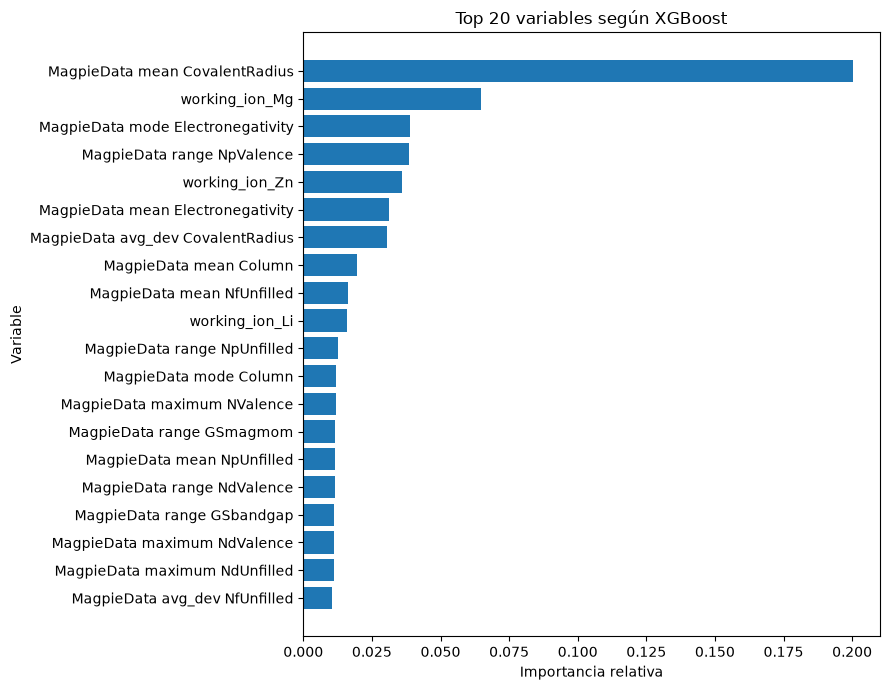

In [7]:
top_native = (
    native_importance
    .head(TOP_N_FEATURES)
    .sort_values(
        "importance",
        ascending=True,
    )
)

plt.figure(figsize=(9, 7))

plt.barh(
    top_native["feature"],
    top_native["importance"],
)

plt.xlabel("Importancia relativa")
plt.ylabel("Variable")

plt.title(
    f"Top {TOP_N_FEATURES} variables según XGBoost"
)

plt.tight_layout()
plt.show()

## Importancia de permutación

### 7. Calcular la importancia de permutación sobre TEST

Esta técnica mide cuánto empeora el rendimiento del modelo cuando se desordena aleatoriamente una variable.
Si al permutar una variable el error aumenta, significa que esa información era relevante para realizar buenas predicciones.

In [8]:
perm_result = permutation_importance(
    estimator=xgb_voltage,
    X=X_test,
    y=y_test,
    scoring="neg_mean_absolute_error",
    n_repeats=N_REPEATS_PERMUTATION,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

permutation_df = pd.DataFrame(
    {
        "feature": X_test.columns,
        "importance_mean": (
            perm_result.importances_mean
        ),
        "importance_std": (
            perm_result.importances_std
        ),
    }
)

permutation_df = (
    permutation_df
    .sort_values(
        "importance_mean",
        ascending=False,
    )
    .reset_index(drop=True)
)

permutation_df["rank"] = np.arange(
    1,
    len(permutation_df) + 1,
)

display(
    permutation_df.head(
        TOP_N_FEATURES
    )
)

,feature,importance_mean,importance_std,rank
0,MagpieData mean CovalentRadius,0.285021,0.010233,1
1,working_ion_Mg,0.166273,0.007072,2
2,working_ion_Zn,0.126118,0.006266,3
3,MagpieData mean Electronegativity,0.113564,0.008066,4
4,MagpieData mean NpUnfilled,0.044134,0.003309,5
5,MagpieData mean SpaceGroupNumber,0.041732,0.002685,6
6,MagpieData avg_dev SpaceGroupNumber,0.040863,0.004730,7
7,MagpieData mean GSvolume_pa,0.037372,0.004312,8
8,MagpieData avg_dev CovalentRadius,0.033801,0.002822,9
9,MagpieData mean NpValence,0.030594,0.003716,10


### 8. Gráfico de importancia de permutación

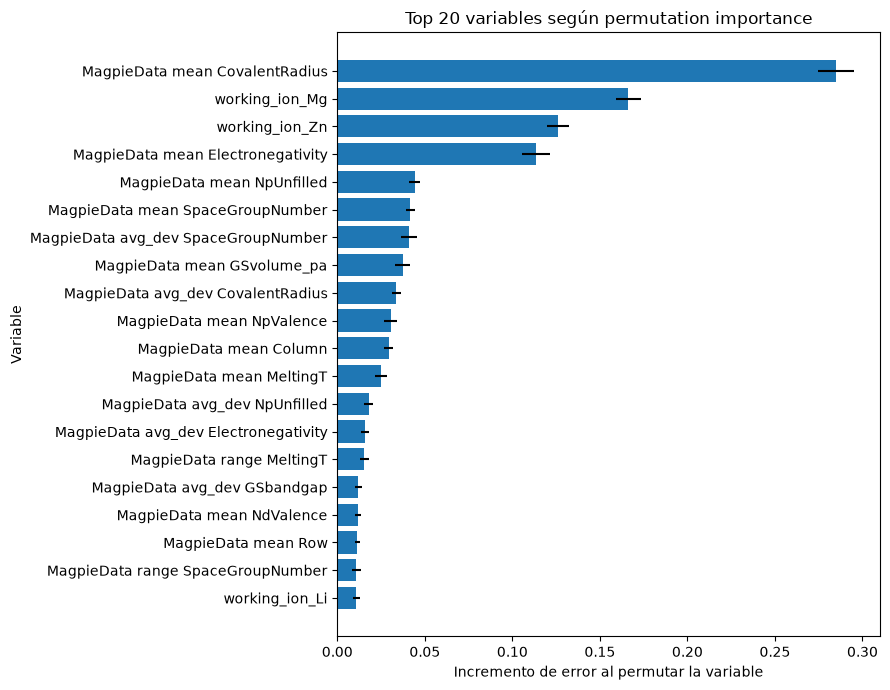

In [9]:
top_perm = (
    permutation_df
    .head(TOP_N_FEATURES)
    .sort_values(
        "importance_mean",
        ascending=True,
    )
)

plt.figure(figsize=(9, 7))

plt.barh(
    top_perm["feature"],
    top_perm["importance_mean"],
    xerr=top_perm["importance_std"],
)

plt.xlabel(
    "Incremento de error al permutar la variable"
)

plt.ylabel("Variable")

plt.title(
    f"Top {TOP_N_FEATURES} variables según permutation importance"
)

plt.tight_layout()
plt.show()

## Comparación de ambas medidas

### 9. Comparar importancia nativa y de permutación

Las dos medidas pueden producir rankings diferentes:

- la nativa describe el uso de las variables dentro de los árboles;
- la permutacion evalúa cuánto depende el rendimiento en test de cada variable.

In [10]:
comparison = (
    native_importance[
        ["feature", "importance"]
    ]
    .merge(
        permutation_df[
            [
                "feature",
                "importance_mean",
                "importance_std",
            ]
        ],
        on="feature",
        how="inner",
    )
)

comparison = (
    comparison
    .sort_values(
        "importance_mean",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    comparison.head(
        TOP_N_FEATURES
    )
)

,feature,importance,importance_mean,importance_std
0,MagpieData mean CovalentRadius,0.200147,0.285021,0.010233
1,working_ion_Mg,0.064855,0.166273,0.007072
2,working_ion_Zn,0.035864,0.126118,0.006266
3,MagpieData mean Electronegativity,0.031407,0.113564,0.008066
4,MagpieData mean NpUnfilled,0.011477,0.044134,0.003309
5,MagpieData mean SpaceGroupNumber,0.008539,0.041732,0.002685
6,MagpieData avg_dev SpaceGroupNumber,0.004803,0.040863,0.004730
7,MagpieData mean GSvolume_pa,0.007266,0.037372,0.004312
8,MagpieData avg_dev CovalentRadius,0.030568,0.033801,0.002822
9,MagpieData mean NpValence,0.008935,0.030594,0.003716


## Magpie frente a working ion

### 10. Agrupar variables por familia

El feature engineering original combina:

- descriptores Magpie del framework;
- variables dummy de `working_ion`.

In [11]:
def feature_family(feature_name):
    if str(feature_name).startswith(
        "working_ion_"
    ):
        return "Working ion"

    return "Magpie"


comparison["feature_family"] = (
    comparison["feature"]
    .apply(feature_family)
)

family_summary = (
    comparison
    .groupby(
        "feature_family",
        as_index=False,
    )
    .agg(
        native_importance_total=(
            "importance",
            "sum",
        ),
        permutation_importance_total=(
            "importance_mean",
            "sum",
        ),
        n_features=(
            "feature",
            "count",
        ),
    )
)

display(family_summary)

,feature_family,native_importance_total,permutation_importance_total,n_features
0,Magpie,0.862092,1.043807,132
1,Working ion,0.137908,0.323391,10


### 11. Importancia agregada por familia

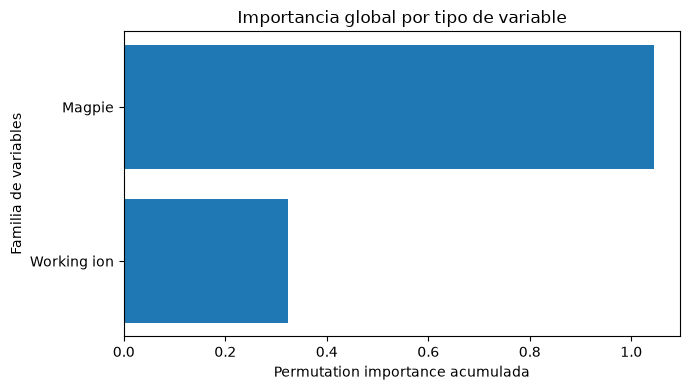

In [12]:
family_plot = (
    family_summary
    .sort_values(
        "permutation_importance_total",
        ascending=True,
    )
)

plt.figure(figsize=(7, 4))

plt.barh(
    family_plot["feature_family"],
    family_plot["permutation_importance_total"],
)

plt.xlabel(
    "Permutation importance acumulada"
)

plt.ylabel("Familia de variables")

plt.title(
    "Importancia global por tipo de variable"
)

plt.tight_layout()
plt.show()

## Análisis de errores

### 12. Crear tabla de errores

In [13]:
errors_df = pd.DataFrame(
    {
        "y_real": np.asarray(y_test),
        "y_pred": np.asarray(y_pred),
    }
)

errors_df["error"] = (
    errors_df["y_pred"]
    - errors_df["y_real"]
)

errors_df["abs_error"] = np.abs(
    errors_df["error"]
)

display(errors_df.head())

,y_real,y_pred,error,abs_error
0,3.369767,3.510944,0.141177,0.141177
1,2.492849,3.699946,1.207097,1.207097
2,3.185939,2.675599,-0.510340,0.510340
3,0.084590,0.169813,0.085223,0.085223
4,3.681828,3.965677,0.283850,0.283850


### 13. Voltaje real frente a predicho

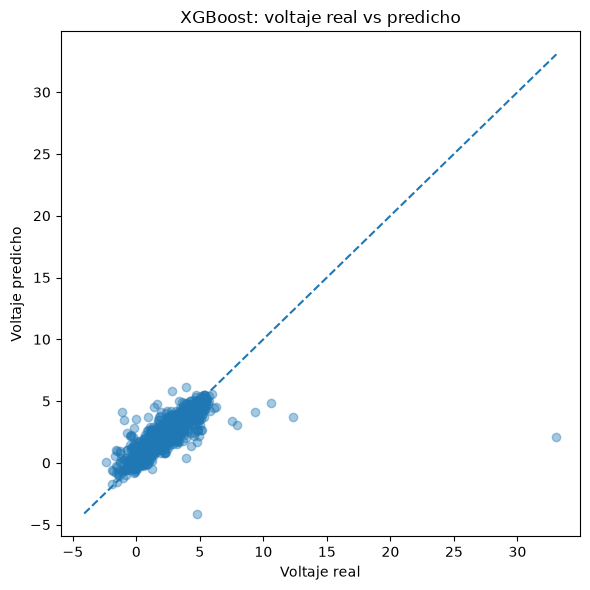

In [14]:
plt.figure(figsize=(6, 6))

plt.scatter(
    errors_df["y_real"],
    errors_df["y_pred"],
    alpha=0.4,
)

minimum = min(
    errors_df["y_real"].min(),
    errors_df["y_pred"].min(),
)

maximum = max(
    errors_df["y_real"].max(),
    errors_df["y_pred"].max(),
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--",
)

plt.xlabel("Voltaje real")
plt.ylabel("Voltaje predicho")
plt.title("XGBoost: voltaje real vs predicho")

plt.tight_layout()
plt.show()

### 14. Residuos frente al voltaje predicho

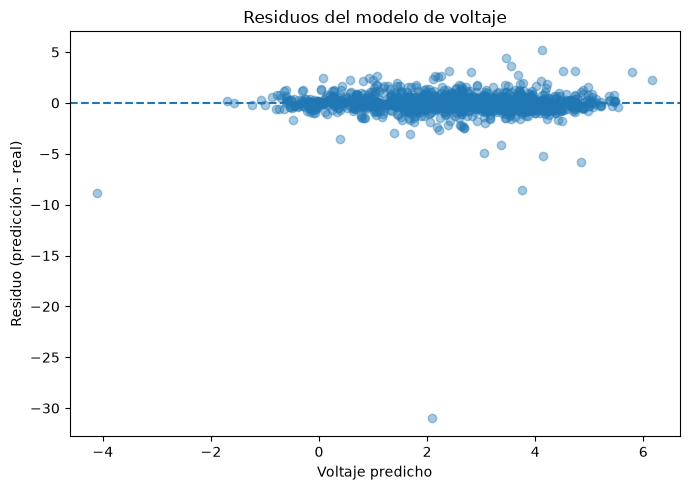

In [15]:
plt.figure(figsize=(7, 5))

plt.scatter(
    errors_df["y_pred"],
    errors_df["error"],
    alpha=0.4,
)

plt.axhline(
    0,
    linestyle="--",
)

plt.xlabel("Voltaje predicho")
plt.ylabel(
    "Residuo (predicción - real)"
)

plt.title(
    "Residuos del modelo de voltaje"
)

plt.tight_layout()
plt.show()

### 15. Casos con mayor error absoluto

In [16]:
worst_errors = (
    errors_df
    .sort_values(
        "abs_error",
        ascending=False,
    )
    .head(20)
)

display(worst_errors)

,y_real,y_pred,error,abs_error
360,33.065771,2.086143,-30.979628,30.979628
734,4.780452,-4.099981,-8.880433,8.880433
1240,12.296080,3.747890,-8.548190,8.548190
238,10.623050,4.848952,-5.774098,5.774098
275,-1.105194,4.122541,5.227735,5.227735
345,9.322973,4.141357,-5.181616,5.181616
912,7.960390,3.048087,-4.912303,4.912303
1335,-0.979430,3.451312,4.430743,4.430743
480,7.505595,3.363468,-4.142127,4.142127
604,-0.048828,3.549363,3.598191,3.598191


## Error según el rango de voltaje

### 16. Dividir el target en cuartiles

In [17]:
errors_df["voltage_range"] = pd.qcut(
    errors_df["y_real"],
    q=4,
    duplicates="drop",
)

error_by_range = (
    errors_df
    .groupby(
        "voltage_range",
        observed=True,
    )
    .agg(
        n=("abs_error", "size"),
        MAE=("abs_error", "mean"),
        MedAE=("abs_error", "median"),
        mean_real_voltage=(
            "y_real",
            "mean",
        ),
    )
    .reset_index()
)

display(error_by_range)

,voltage_range,n,MAE,MedAE,mean_real_voltage
0,"(-2.404, 1.324]",343,0.623276,0.380280,0.256650
1,"(1.324, 2.707]",342,0.480069,0.344847,2.092803
2,"(2.707, 3.746]",342,0.392773,0.283869,3.241893
3,"(3.746, 33.066]",343,0.752561,0.428854,4.619492


### 17. Gráfico del MAE por rango

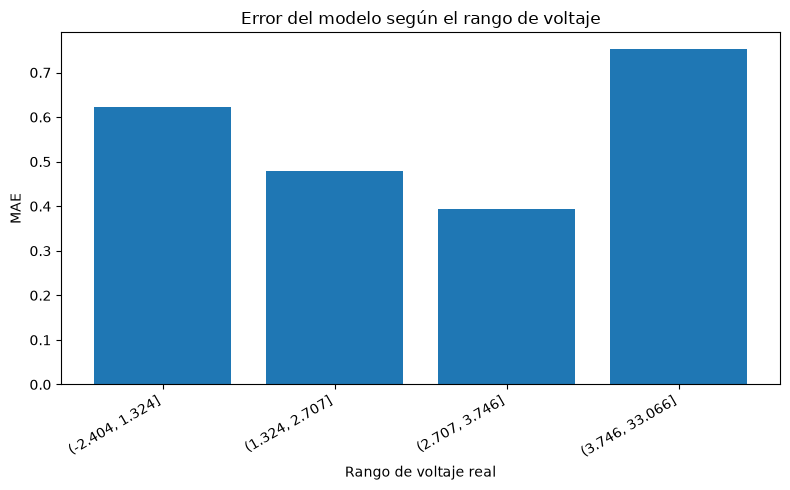

In [18]:
error_by_range_plot = (
    error_by_range.copy()
)

error_by_range_plot[
    "voltage_range"
] = (
    error_by_range_plot[
        "voltage_range"
    ].astype(str)
)

plt.figure(figsize=(8, 5))

plt.bar(
    error_by_range_plot[
        "voltage_range"
    ],
    error_by_range_plot[
        "MAE"
    ],
)

plt.xlabel("Rango de voltaje real")
plt.ylabel("MAE")

plt.title(
    "Error del modelo según el rango de voltaje"
)

plt.xticks(
    rotation=30,
    ha="right",
)

plt.tight_layout()
plt.show()

## Exportar resultados para Tableau

In [19]:
native_importance.to_csv(
    OUTPUT_DIR
    / "xgb_feature_importance.csv",
    index=False,
)

permutation_df.to_csv(
    OUTPUT_DIR
    / "xgb_permutation_importance.csv",
    index=False,
)

comparison.to_csv(
    OUTPUT_DIR
    / "xgb_importance_comparison.csv",
    index=False,
)

family_summary.to_csv(
    OUTPUT_DIR
    / "xgb_importance_by_family.csv",
    index=False,
)

errors_df.to_csv(
    OUTPUT_DIR
    / "xgb_voltage_test_predictions.csv",
    index=False,
)

error_by_range.to_csv(
    OUTPUT_DIR
    / "xgb_error_by_voltage_range.csv",
    index=False,
)

print(
    "Resultados guardados en:",
    OUTPUT_DIR
)

Resultados guardados en: resultados_interpretabilidad
